# K-Nearest Neighbors Classification

## Overview

The **K-Nearest Neighbors (K-NN)** algorithm is one of the simplest and most intuitive classification methods.
Given a labeled training set $\{(x_i, y_i)\}_{i=1}^n$ and a query point $x$, K-NN assigns a class by
majority vote among the $k$ closest training points.

### Why K-NN Matters

K-NN is a **non-parametric** method: it makes no assumption about the shape of the decision boundary.
This makes it extremely flexible but also sensitive to noise and the choice of $k$.
Understanding K-NN illuminates core machine learning concepts:

- The **bias-variance tradeoff**: small $k$ gives jagged, low-bias but high-variance boundaries;
  large $k$ smooths the boundary but introduces bias.
- The **curse of dimensionality**: distance concentrates as dimension grows, degrading K-NN performance.
- **Decision regions** and Voronoi diagrams: the $k=1$ boundary is exactly the Voronoi diagram of the training set.

### What This Notebook Demonstrates

1. Synthetic two-class data from two Gaussian blobs.
2. Decision boundaries for $k = 1, 3, 5, 15$ shown in a multi-panel comparison.
3. How the boundary smooths as $k$ increases.
4. An interactive slider to explore any $k$.
5. Leave-one-out error as a function of $k$.

### Classification Rule

Given query $x$, let $\mathcal{N}_k(x)$ denote the index set of the $k$ nearest training points
(in Euclidean distance). The predicted label is

$$
\hat{y}(x) = \operatorname{majority}\bigl(\{y_i : i \in \mathcal{N}_k(x)\}\bigr).
$$

For a two-class problem with labels $\{0, 1\}$, this is equivalent to

$$
\hat{y}(x) = \mathbf{1}\!\left[\frac{1}{k}\sum_{i \in \mathcal{N}_k(x)} y_i \geq \frac{1}{2}\right].
$$

### Bias-Variance Perspective

The expected prediction error decomposes as

$$
\mathbb{E}\bigl[(\hat{y}(x) - y(x))^2\bigr] = \underbrace{\operatorname{Bias}^2[\hat{y}(x)]}_{\text{increases with } k} + \underbrace{\operatorname{Var}[\hat{y}(x)]}_{\text{decreases with } k} + \sigma^2_{\text{noise}}.
$$

### Setup and Data Generation

We generate two isotropic Gaussian blobs in $\mathbb{R}^2$:

$$
\text{Class 0}: x \sim \mathcal{N}(\mu_0, \sigma^2 I), \quad
\text{Class 1}: x \sim \mathcal{N}(\mu_1, \sigma^2 I),
$$

with $\mu_0 = (-1, 0)$, $\mu_1 = (1, 0)$, and $\sigma = 0.9$.
We use `scipy.spatial.cKDTree` for efficient nearest-neighbor queries on a dense evaluation grid.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial import cKDTree

rng = np.random.default_rng(42)

n_per_class = 80
sigma_blob = 0.9

X0 = rng.normal(loc=[-1.0, 0.0], scale=sigma_blob, size=(n_per_class, 2))
X1 = rng.normal(loc=[ 1.0, 0.0], scale=sigma_blob, size=(n_per_class, 2))
X_train = np.vstack([X0, X1])
y_train = np.array([0]*n_per_class + [1]*n_per_class)

# Dense evaluation grid
grid_res = 200
xx, yy = np.meshgrid(np.linspace(-3.5, 3.5, grid_res),
                     np.linspace(-3.0, 3.0, grid_res))
X_grid = np.column_stack([xx.ravel(), yy.ravel()])

# Build cKDTree once
tree = cKDTree(X_train)

print(f"Training set: {X_train.shape[0]} points  (classes: {n_per_class} each)")
print(f"Grid: {grid_res}x{grid_res} = {X_grid.shape[0]} evaluation points")

Training set: 160 points  (classes: 80 each)
Grid: 200x200 = 40000 evaluation points


### Computing Decision Regions for Multiple $k$

For each query point $x$ on the grid we query the $k$ nearest neighbors from the tree,
then apply the majority vote rule:

$$
\hat{p}_k(x) = \frac{1}{k} \sum_{i \in \mathcal{N}_k(x)} y_i \in [0,1].
$$

The predicted class is $\mathbf{1}[\hat{p}_k(x) \geq 0.5]$.
We display the **soft probability** $\hat{p}_k(x)$ as a continuous colormap to reveal the
confidence of the classifier, not just the hard boundary.

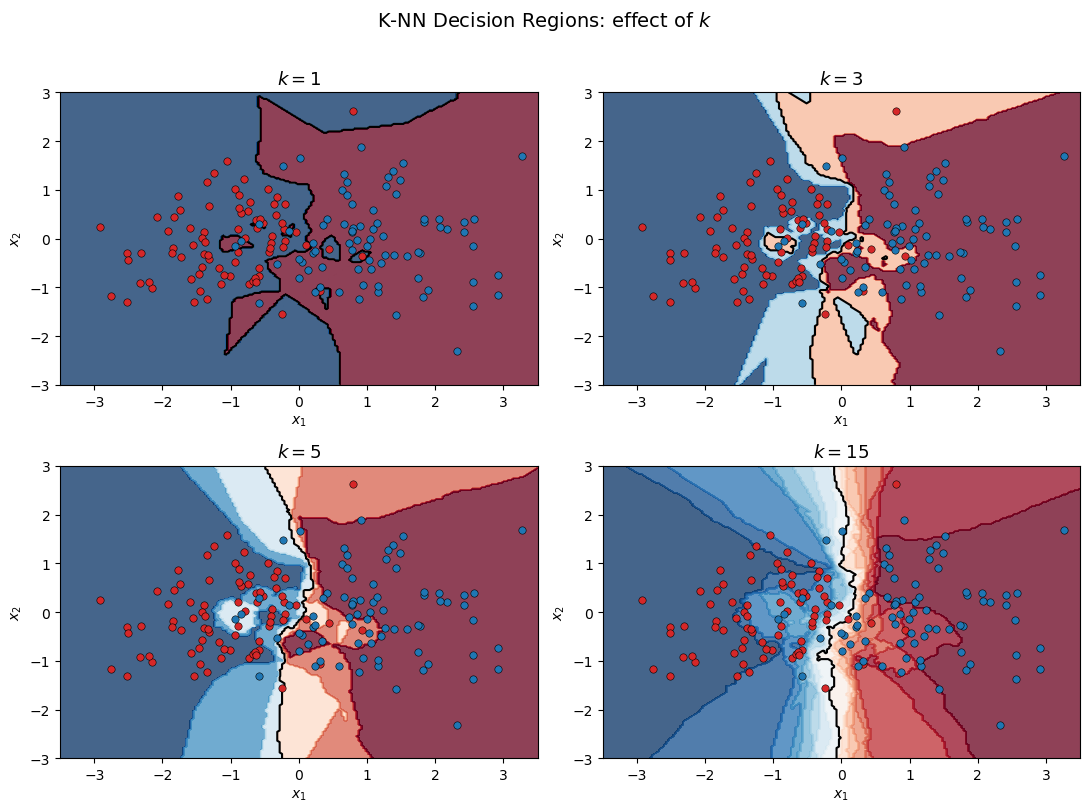

In [2]:
k_values = [1, 3, 5, 15]

def knn_predict_proba(k, X_grid, tree, y_train):
    """Return soft probability P(class=1) for each grid point."""
    _, idx = tree.query(X_grid, k=k)
    if k == 1:
        idx = idx[:, np.newaxis]
    return y_train[idx].mean(axis=1)

cmap_bg = plt.cm.RdBu_r
cmap_pts = {0: '#d62728', 1: '#1f77b4'}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()

for ax, k in zip(axes, k_values):
    proba = knn_predict_proba(k, X_grid, tree, y_train)
    Z = proba.reshape(grid_res, grid_res)

    ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 101),
                cmap=cmap_bg, alpha=0.75, vmin=0, vmax=1)
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=1.5)

    for cls, color in cmap_pts.items():
        mask = y_train == cls
        ax.scatter(X_train[mask, 0], X_train[mask, 1],
                   c=color, edgecolors='k', linewidths=0.4, s=28, zorder=5)

    ax.set_title(f'$k = {k}$', fontsize=13)
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.0, 3.0)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

fig.suptitle('K-NN Decision Regions: effect of $k$', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('decision_regions.png', dpi=90, bbox_inches='tight')
plt.show()

### Leave-One-Out Cross-Validation Error

The leave-one-out (LOO) error for K-NN is defined as

$$
\text{LOO}(k) = \frac{1}{n} \sum_{i=1}^n \mathbf{1}\bigl[\hat{y}^{(-i)}_k(x_i) \neq y_i\bigr],
$$

where $\hat{y}^{(-i)}_k$ is the K-NN classifier trained on all points except $i$.
For K-NN, LOO reduces to querying $k+1$ neighbors (including self) and excluding the query point itself,
which we implement efficiently with the cKDTree.

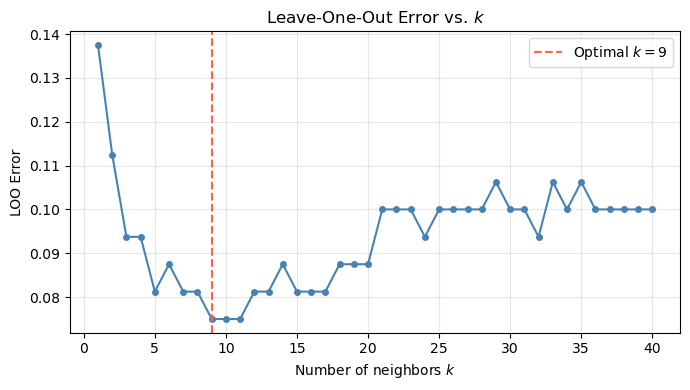

Best k (LOO): 9  (error=0.075)


In [3]:
k_range = np.arange(1, 41)
loo_errors = []

for k in k_range:
    # Query k+1 neighbors (first is the point itself)
    _, idx = tree.query(X_train, k=k+1)
    neighbor_labels = y_train[idx[:, 1:]]   # exclude self
    preds = (neighbor_labels.mean(axis=1) >= 0.5).astype(int)
    loo_errors.append(np.mean(preds != y_train))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_range, loo_errors, 'o-', color='steelblue', markersize=4)
ax.axvline(k_range[np.argmin(loo_errors)], color='tomato', linestyle='--',
           label=f'Optimal $k={k_range[np.argmin(loo_errors)]}$')
ax.set_xlabel('Number of neighbors $k$')
ax.set_ylabel('LOO Error')
ax.set_title('Leave-One-Out Error vs. $k$')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loo_error.png', dpi=90, bbox_inches='tight')
plt.show()

print(f"Best k (LOO): {k_range[np.argmin(loo_errors)]}  (error={min(loo_errors):.3f})")

### Static Snapshot

The cell below generates the representative `snippet.png` image used in the repository gallery.
It reproduces the four-panel decision region figure in a compact square format.
Set `STATIC_SNAPSHOT = True` to regenerate it.

In [4]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    import numpy as _np
    from scipy.spatial import cKDTree as _cKDTree

    _rng = _np.random.default_rng(42)
    _npc = 80
    _X0 = _rng.normal([-1, 0], 0.9, (_npc, 2))
    _X1 = _rng.normal([ 1, 0], 0.9, (_npc, 2))
    _X  = _np.vstack([_X0, _X1])
    _y  = _np.array([0]*_npc + [1]*_npc)
    _tree = _cKDTree(_X)

    _g = 160
    _xx, _yy = _np.meshgrid(_np.linspace(-3.5, 3.5, _g), _np.linspace(-3, 3, _g))
    _Xg = _np.column_stack([_xx.ravel(), _yy.ravel()])

    _fig, _axes = _plt.subplots(2, 2, figsize=(6, 6))
    _axes = _axes.ravel()
    for _ax, _k in zip(_axes, [1, 3, 5, 15]):
        _, _idx = _tree.query(_Xg, k=_k)
        if _k == 1: _idx = _idx[:, _np.newaxis]
        _Z = _y[_idx].mean(axis=1).reshape(_g, _g)
        _ax.contourf(_xx, _yy, _Z, levels=_np.linspace(0, 1, 51), cmap='RdBu_r', alpha=0.8)
        _ax.contour(_xx, _yy, _Z, levels=[0.5], colors='k', linewidths=1.2)
        for _c, _col in {0:'#d62728', 1:'#1f77b4'}.items():
            _m = _y == _c
            _ax.scatter(_X[_m,0], _X[_m,1], c=_col, edgecolors='k', lw=0.3, s=14, zorder=5)
        _ax.set_title(f'$k={_k}$', fontsize=10)
        _ax.set_xticks([]); _ax.set_yticks([])
    _fig.suptitle('K-NN Decision Regions', fontsize=11)
    _plt.tight_layout()
    _plt.savefig('snippet.png', dpi=100, bbox_inches='tight')
    _plt.close(_fig)
    print('snippet.png saved.')

snippet.png saved.


### Interactive Exploration

Use the slider below to explore how the decision boundary changes with $k$.
As $k$ increases from 1 toward $n$, the boundary transitions from the Voronoi diagram
of the training set to a single global decision.

The **soft probability** $\hat{p}_k(x)$ is shown: blue = class 1 confident,
red = class 0 confident, white = uncertain ($\hat{p} \approx 0.5$).

## Takeaways

- **K-NN is non-parametric**: it memorizes the training set and makes predictions by local voting.
  There is no explicit training phase beyond storing data.
- **$k=1$** recovers the Voronoi diagram of the training set: the decision boundary is
  piecewise-linear and adapts tightly to every training point.
- **Increasing $k$** smooths the boundary: more points vote, reducing variance but
  increasing bias (the boundary can no longer follow all local fluctuations).
- **LOO cross-validation** is a natural way to select $k$ without a held-out test set,
  exploiting the efficient self-exclusion trick.
- **Scalability**: brute-force K-NN is $\mathcal{O}(nd)$ per query; `cKDTree` reduces
  this to $\mathcal{O}(d \log n)$ in low dimension, but suffers from the curse of dimensionality.

## Bibliography

- T. Cover and P. Hart, *Nearest Neighbor Pattern Classification*, IEEE Trans. Inf. Theory, 1967.
- T. Hastie, R. Tibshirani, J. Friedman, *The Elements of Statistical Learning*, Springer, 2009.
  Chapter 13: Prototype Methods and Nearest-Neighbors.
- C. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006. Chapter 2.